In [1]:
import joblib             as jlb
import matplotlib.pyplot  as plt
import warnings
warnings.filterwarnings('ignore')

from collections          import Counter
from sklearn.cluster      import KMeans
from Customer_dataset import data
processed_data=data.copy()
print(processed_data.head(10))

   Age  Income_Level  Date_num  Gender_Male  Occupation_Doctor  \
0   23         70541      2908            0                  0   
1   26         54168      2698            1                  0   
2   29         73899      1756            0                  0   
3   20         63381      2763            1                  0   
4   25         38794      2755            0                  0   
5   41         87188      2015            0                  0   
6   55         94891      1727            1                  0   
7   35         61003      1607            1                  0   
8   43        116249      2014            0                  0   
9   32         49083      2163            0                  0   

   Occupation_Engineer  Occupation_Entrepreneur  Occupation_Lawyer  \
0                    0                        1                  0   
1                    0                        0                  0   
2                    0                        1                

In [2]:
##------------------------------------------------------------------------------
## Xây dựng mô hình kMeans
##------------------------------------------------------------------------------
k     = 5
Kmeans_model = KMeans(n_clusters = k)
Kmeans_model.fit(data)  # xây dựng mô hình

,n_clusters,5
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [3]:
## Lưu trữ mô hình để khai thác về sau
jlb.dump(Kmeans_model,'../customer_clustering/Output/kMeans.mdl')

['../customer_clustering/Output/kMeans.mdl']

In [4]:
## Khai thác mô hình đã được xây dựng
Loaded_Kmeans_model = jlb.load('../customer_clustering/Output/kMeans.mdl')

In [5]:
## Các trọng tâm
print(f'*** {k} trọng tâm:')
print(Loaded_Kmeans_model.cluster_centers_)

*** 5 trọng tâm:
[[4.57511962e+01 1.15274976e+05 1.87868421e+03 5.45454545e-01
  1.67464115e-01 1.14832536e-01 1.10047847e-01 1.05263158e-01
  1.05263158e-01 8.61244019e-02 1.38755981e-01 8.61244019e-02]
 [4.49008621e+01 6.20449914e+04 1.89452586e+03 5.04310345e-01
  6.89655172e-02 1.12068966e-01 1.03448276e-01 1.42241379e-01
  1.07758621e-01 8.18965517e-02 1.42241379e-01 1.50862069e-01]
 [4.54172185e+01 1.39654530e+05 1.89286093e+03 4.96688742e-01
  1.12582781e-01 1.12582781e-01 1.45695364e-01 9.27152318e-02
  7.28476821e-02 5.96026490e-02 1.58940397e-01 1.32450331e-01]
 [4.42817680e+01 8.93099779e+04 1.89250276e+03 5.24861878e-01
  1.32596685e-01 5.52486188e-02 1.27071823e-01 8.83977901e-02
  9.39226519e-02 1.16022099e-01 1.54696133e-01 1.16022099e-01]
 [4.40704846e+01 3.47659251e+04 1.92939648e+03 5.28634361e-01
  6.60792952e-02 1.14537445e-01 1.14537445e-01 1.40969163e-01
  1.36563877e-01 8.37004405e-02 1.27753304e-01 1.10132159e-01]]


In [6]:
## Kết quả gom cụm khách hàng
centroids       = Loaded_Kmeans_model.cluster_centers_
data['cluster'] = Loaded_Kmeans_model.labels_
print(data.head(5))

print('\nKích thước các clusters:', Counter(Loaded_Kmeans_model.labels_))
print('\nClusters lớn nhất:', Counter(Loaded_Kmeans_model.labels_).most_common(1))

   Age  Income_Level  Date_num  Gender_Male  Occupation_Doctor  \
0   23         70541      2908            0                  0   
1   26         54168      2698            1                  0   
2   29         73899      1756            0                  0   
3   20         63381      2763            1                  0   
4   25         38794      2755            0                  0   

   Occupation_Engineer  Occupation_Entrepreneur  Occupation_Lawyer  \
0                    0                        1                  0   
1                    0                        0                  0   
2                    0                        1                  0   
3                    0                        1                  0   
4                    0                        0                  0   

   Occupation_Manager  Occupation_Nurse  Occupation_Salesperson  \
0                   0                 0                       0   
1                   1                 0         

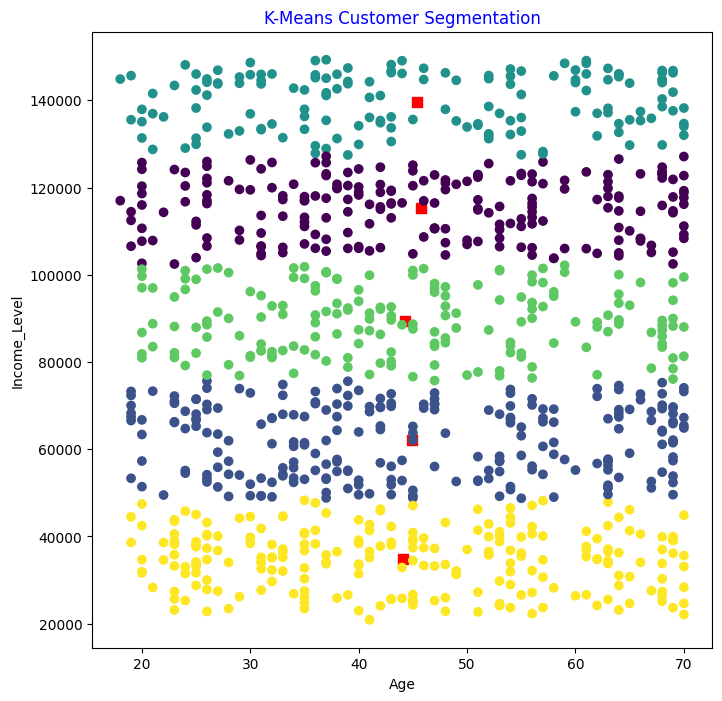

In [7]:
## Biểu diễn trực quan
plt.figure(figsize = (8, 8))
plt.scatter(centroids[:, 0], centroids[:, 1], marker = "s", s = 50, color = 'r')
plt.scatter(processed_data.Age, processed_data['Income_Level'], c = data.cluster)
plt.xlabel("Age")
plt.ylabel("Income_Level")
plt.title("K-Means Customer Segmentation", color = "blue")
plt.show()